# Xenium Prime 5K Breast — V1002 CCC-only automatic niches

CCC-only flat NMF first learns 32 interpretable programs. Final niche number is then selected from cell-level program usage. No composition or Full factorization is fitted.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path('/data1/xueshuailin/CCC_Phe_Niche')
V1002 = Path('/home/xueshuailin/CCC_Phe/V1002')
SOURCE = V1002 / 'src'
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0, str(SOURCE))
import numpy as np, pandas as pd, anndata as ad, matplotlib.pyplot as plt, seaborn as sns, torch
from scipy.spatial import cKDTree
from scipy.stats import rankdata, tiecorrect, norm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from phenoniche.v1001.neighborhoods import build_neighborhoods
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression, aggregate_pairwise_ccc
from phenoniche.v1002.final_model import fit_balanced
SEED=40700; N_NEIGHBORS=30; SIGMA_UM=20.; PROGRAMS=32; K_MIN=4; K_MAX=15
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'
OUT=V1002/'outputs/xenium_prime_5k_ccc_autok32'; OUT.mkdir(parents=True,exist_ok=True)
REVISION='v1002_ccc_autok32_cell_usage_v1'
rng=np.random.default_rng(SEED)


## 1. Prime 5K data summary

In [2]:
path=ROOT/'data/xenium_prime_5k_breast/processed/XeniumPrime5K_Breast_V1002_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_Prime_Breast_Cancer_FFPE'
coordinates=np.asarray(adata.obsm['spatial'],dtype=np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
T=len(label_categories); N=adata.n_obs


## 2. V1002 directed CCC and 32-program NMF

In [3]:
neighborhoods=build_neighborhoods(coordinates,k=N_NEIGHBORS,sigma=SIGMA_UM)
members=neighborhoods.indices.reshape(N,N_NEIGHBORS)
anchor_weights=neighborhoods.weights.reshape(N,N_NEIGHBORS).astype(np.float32)
C,_,opportunity=aggregate_pairwise_ccc(coordinates,cell_type,np.zeros((N,1),np.float32),np.zeros((N,1),np.float32),
    T,sigma=SIGMA_UM,members=members,anchor_weights=anchor_weights,batch_size=256,device=DEVICE,compute_signal=False)
atlas=load_lr_atlas(str(V1002/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(r for r in atlas.interactions if all(g in panel for g in r.ligand_components+r.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
lr_genes=tuple(sorted({g for r in measurable for g in r.ligand_components+r.receptor_components}))
lookup={g.upper():g for g in adata.var_names}
expression=adata[:,[lookup[g] for g in lr_genes]].X.toarray().astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas); del expression
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
pair_support=(opportunity>0).sum(0)
feature_mask=(coverage&(pair_support>=max(20,int(np.ceil(.01*N))))[:,None]).reshape(-1)
feature_indices=np.flatnonzero(feature_mask); pair_index,lr_index=np.divmod(feature_indices,len(measurable))
sender_index,receiver_index=np.divmod(pair_index,T)
ccc_mapping=pd.DataFrame({'feature_id':np.arange(len(feature_indices)),'flat_feature_index':feature_indices,
    'sender':np.asarray(label_categories)[sender_index],'receiver':np.asarray(label_categories)[receiver_index],
    'lr':[measurable[i].lr_id for i in lr_index]})
ccc_mapping['ccc']=ccc_mapping.sender+' → '+ccc_mapping.receiver+' | '+ccc_mapping.lr
ccc_mapping.to_csv(OUT/'ccc_features.csv',index=False)
I_path=OUT/'I_CCC.npy'
if I_path.is_file() and np.load(I_path,mmap_mode='r').shape==(N,len(feature_indices)):
    I=np.load(I_path,mmap_mode='r')
else:
    temporary=OUT/'I_CCC.incomplete.npy'
    I=np.lib.format.open_memmap(temporary,mode='w+',dtype=np.float32,shape=(N,len(feature_indices)))
    _,I,check=aggregate_pairwise_ccc(coordinates,cell_type,ligand,receptor,T,sigma=SIGMA_UM,
        members=members,anchor_weights=anchor_weights,feature_mask=feature_mask,batch_size=256,
        device=DEVICE,communication_out=I)
    assert np.allclose(opportunity,check,rtol=1e-5,atol=1e-6)
    I.flush(); del I; temporary.replace(I_path); I=np.load(I_path,mmap_mode='r')
display(pd.Series({'cells':N,'genes':adata.n_vars,'retained CCC features':I.shape[1],
                   'initial CCC programs':PROGRAMS},name='V1002 CCC-only'))


cells                    699110
genes                      5101
retained CCC features       494
initial CCC programs         32
Name: V1002 CCC-only, dtype: int64

In [5]:
p_path,h_path,a_path=OUT/'P32.npy',OUT/'H32.npy',OUT/'activity.npy'
if all(p.is_file() for p in (p_path,h_path,a_path)):
    P32=np.load(p_path,mmap_mode='r'); H32=np.load(h_path); activity=np.load(a_path,mmap_mode='r')
else:
    fit32=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=PROGRAMS)
    W32=np.maximum(fit32.W.numpy(),0); activity=W32.sum(1).astype(np.float32)
    P32=(W32/np.maximum(activity[:,None],1e-12)).astype(np.float32)
    H32=np.maximum(fit32.dictionaries['HI'].numpy(),0).astype(np.float32)
    np.save(p_path,P32); np.save(h_path,H32); np.save(a_path,activity)
    (OUT/'nmf32_audit.json').write_text(json.dumps(fit32.audit,indent=2))
    P32=np.load(p_path,mmap_mode='r'); activity=np.load(a_path,mmap_mode='r')
# Rows with no retained CCC signal have W32.sum()==0. Represent them as a
# uniform program mixture while activity=0 records that no CCC was observed.
# This creates a reproducible no-CCC/background state and avoids argmax-to-program-1 artifacts.
p32_rw=np.load(p_path,mmap_mode='r+')
for start in range(0,N,50000):
    stop=min(start+50000,N); block=np.asarray(p32_rw[start:stop]).copy(); row_sum=block.sum(1)
    zero=row_sum<=1e-12
    block[zero]=1.0/PROGRAMS
    block[~zero]/=row_sum[~zero,None]
    p32_rw[start:stop]=block
p32_rw.flush(); del p32_rw
P32=np.load(p_path,mmap_mode='r')
assert P32.shape==(N,32) and H32.shape==(32,I.shape[1])
assert np.allclose(np.asarray(P32[:10000]).sum(1),1,atol=1e-5)


## 3. Automatic K selection (4–15)

In [6]:
def scale01(x):
    x=np.asarray(x,float); lo,hi=np.nanmin(x),np.nanmax(x)
    return np.ones_like(x) if hi<=lo else (x-lo)/(hi-lo)
def latent_block(rows,center,scale):
    p=np.asarray(P32[rows],np.float32); a=(np.log1p(np.asarray(activity[rows]))-center)/scale
    return np.column_stack((np.sqrt(np.maximum(p,0)),.25*a)).astype(np.float32)
def soft_membership(distance,temp):
    logits=-distance**2/max(float(temp),1e-8); logits-=logits.max(1,keepdims=True)
    q=np.exp(logits); return q/np.maximum(q.sum(1,keepdims=True),1e-8)

summary_path=OUT/'selection_summary.json'
if summary_path.is_file() and json.loads(summary_path.read_text()).get('revision')==REVISION:
    selection=pd.read_csv(OUT/'K4_15_metrics.csv'); selected_K=int(json.loads(summary_path.read_text())['selected_K'])
    Q=np.load(OUT/'Q_selected.npy',mmap_mode='r'); H=np.load(OUT/'H_selected.npy')
    niche=np.load(OUT/'niche_labels.npy'); confidence=np.load(OUT/'assignment_confidence.npy')
else:
    sample=np.sort(rng.choice(N,min(N,100000),replace=False))
    la=np.log1p(np.asarray(activity[sample])); center=float(np.median(la)); scale=float(np.std(la)) or 1.
    sample_x=latent_block(sample,center,scale)
    probe=sample[:min(10000,len(sample))]
    tree=cKDTree(coordinates); _,near=tree.query(coordinates[probe],k=2); near=near[:,1]
    rows=[]; candidates={}; tiny_cut=max(20,int(np.ceil(.005*N)))
    for k in range(K_MIN,K_MAX+1):
        model=MiniBatchKMeans(n_clusters=k,random_state=SEED,batch_size=4096,n_init=5,max_iter=100).fit(sample_x)
        ds=model.transform(sample_x); temp=float(np.median(ds.min(1)**2)) or 1.
        labels=np.empty(N,np.int16); usage=np.zeros(k); conf_sum=0.
        for start in range(0,N,50000):
            stop=min(start+50000,N); x=latent_block(slice(start,stop),center,scale); d=model.transform(x)
            q=soft_membership(d,temp); labels[start:stop]=d.argmin(1); usage+=q.sum(0); conf_sum+=q.max(1).sum()
        mean_p=np.maximum(model.cluster_centers_[:,:32],0)**2; mean_p/=np.maximum(mean_p.sum(1,keepdims=True),1e-12)
        hk=mean_p@H32; hk/=np.maximum(hk.sum(1,keepdims=True),1e-12)
        hn=hk/np.maximum(np.linalg.norm(hk,axis=1,keepdims=True),1e-12); sep=1-hn@hn.T; off=sep[np.triu_indices(k,1)]
        counts=np.bincount(labels,minlength=k); frac=counts/N
        sil=silhouette_score(sample_x,model.labels_,sample_size=min(10000,len(sample_x)),random_state=SEED)
        rows.append({'K':k,'silhouette':sil,'max_niche_cell_fraction':frac.max(),
            'tiny_niche_fraction':frac[counts<tiny_cut].sum(),'mean_assignment_confidence':conf_sum/N,
            'mean_H_program_separation':off.mean(),'spatial_neighbor_agreement':np.mean(labels[probe]==labels[near]),
            'cell_level_niche_usage':json.dumps((usage/N).tolist()),'cell_niche_counts':json.dumps(counts.tolist())})
        candidates[k]={'model':model,'labels':labels,'H':hk.astype(np.float32),'temp':temp,'center':center,'scale':scale,'mean_p':mean_p}
    selection=pd.DataFrame(rows); selection['ari_previous_K']=np.nan; selection['nmi_previous_K']=np.nan
    for j in range(1,len(selection)):
        a=candidates[int(selection.loc[j-1,'K'])]['labels']; b=candidates[int(selection.loc[j,'K'])]['labels']
        selection.loc[j,'ari_previous_K']=adjusted_rand_score(a,b); selection.loc[j,'nmi_previous_K']=normalized_mutual_info_score(a,b)
    selection['ari_next_K']=selection.ari_previous_K.shift(-1); selection['nmi_next_K']=selection.nmi_previous_K.shift(-1)
    selection['adjacent_K_stability']=selection[['ari_previous_K','nmi_previous_K','ari_next_K','nmi_next_K']].mean(axis=1)
    selection['selection_score']=(.25*scale01(selection.silhouette)+.20*scale01(selection.adjacent_K_stability)
        +.20*scale01(1-selection.max_niche_cell_fraction)+.15*scale01(selection.spatial_neighbor_agreement)
        +.10*scale01(selection.mean_H_program_separation)+.10*scale01(1-selection.tiny_niche_fraction))
    selection['eligible']=(selection.max_niche_cell_fraction<=.75)&(selection.tiny_niche_fraction<=.01)
    eligible=selection[selection.eligible]
    if eligible.empty: eligible=selection[selection.max_niche_cell_fraction<=selection.max_niche_cell_fraction.min()+.05]
    best=eligible.selection_score.max(); selected_K=int(eligible[eligible.selection_score>=best-.05].K.min())
    selection['selected']=selection.K.eq(selected_K); chosen=candidates[selected_K]
    niche=chosen['labels']; H=chosen['H']; Q=np.lib.format.open_memmap(OUT/'Q_selected.npy',mode='w+',dtype=np.float32,shape=(N,selected_K))
    confidence=np.empty(N,np.float32)
    for start in range(0,N,50000):
        stop=min(start+50000,N); q=soft_membership(chosen['model'].transform(latent_block(slice(start,stop),chosen['center'],chosen['scale'])),chosen['temp'])
        Q[start:stop]=q; confidence[start:stop]=q.max(1)
    Q.flush(); np.save(OUT/'H_selected.npy',H); np.save(OUT/'niche_labels.npy',niche); np.save(OUT/'assignment_confidence.npy',confidence)
    selection.to_csv(OUT/'K4_15_metrics.csv',index=False)
    summary={'revision':REVISION,'selected_K':selected_K,'selection_reason':'smallest K on the near-optimal cell-latent stability/quality plateau'}
    summary_path.write_text(json.dumps(summary,indent=2)); Q=np.load(OUT/'Q_selected.npy',mmap_mode='r')
counts=np.bincount(niche,minlength=selected_K); fractions=counts/N


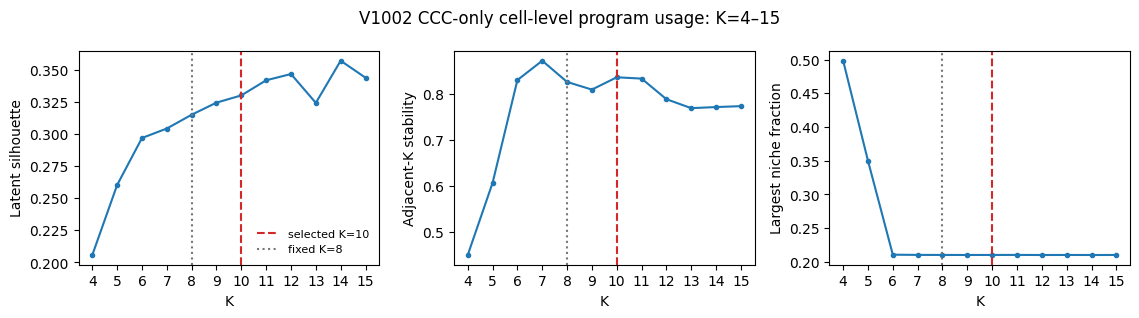

,K,silhouette,adjacent_K_stability,max_niche_cell_fraction,tiny_niche_fraction,mean_assignment_confidence,mean_H_program_separation,spatial_neighbor_agreement,selection_score,eligible,selected
0,4,0.2058,0.4508,0.4982,0.0,0.5126,0.7338,0.8883,0.2412,True,False
1,5,0.2603,0.6073,0.3499,0.0,0.4756,0.7936,0.8994,0.5639,True,False
2,6,0.2969,0.8309,0.2107,0.0,0.4685,0.7516,0.8584,0.7321,True,False
3,7,0.3043,0.8730,0.2104,0.0,0.4374,0.7176,0.8412,0.7145,True,False
4,8,0.3150,0.8268,0.2103,0.0,0.4238,0.7673,0.8353,0.7310,True,False
5,9,0.3244,0.8102,0.2103,0.0,0.4601,0.8020,0.8289,0.7492,True,False
6,10,0.3301,0.8369,0.2103,0.0,0.4239,0.8229,0.8252,0.7778,True,True
7,11,0.3418,0.8341,0.2103,0.0,0.4375,0.8495,0.8246,0.8112,True,False
8,12,0.3467,0.7893,0.2102,0.0,0.4381,0.8540,0.8208,0.7945,True,False
9,13,0.3243,0.7699,0.2103,0.0,0.4325,0.8521,0.8106,0.7298,True,False


In [7]:
fig,axes=plt.subplots(1,3,figsize=(11.5,3.2))
for ax,(column,label) in zip(axes,[('silhouette','Latent silhouette'),('adjacent_K_stability','Adjacent-K stability'),('max_niche_cell_fraction','Largest niche fraction')]):
    ax.plot(selection.K,selection[column],marker='o',ms=3); ax.axvline(selected_K,color='#d62728',ls='--',label=f'selected K={selected_K}')
    ax.axvline(8,color='#777777',ls=':',label='fixed K=8'); ax.set(xlabel='K',ylabel=label); ax.set_xticks(selection.K)
axes[0].legend(frameon=False,fontsize=8); fig.suptitle('V1002 CCC-only cell-level program usage: K=4–15'); fig.tight_layout(); plt.show()
cols=['K','silhouette','adjacent_K_stability','max_niche_cell_fraction','tiny_niche_fraction','mean_assignment_confidence','mean_H_program_separation','spatial_neighbor_agreement','selection_score','eligible','selected']
display(selection[cols].round(4))


## 4. Selected-K spatial map

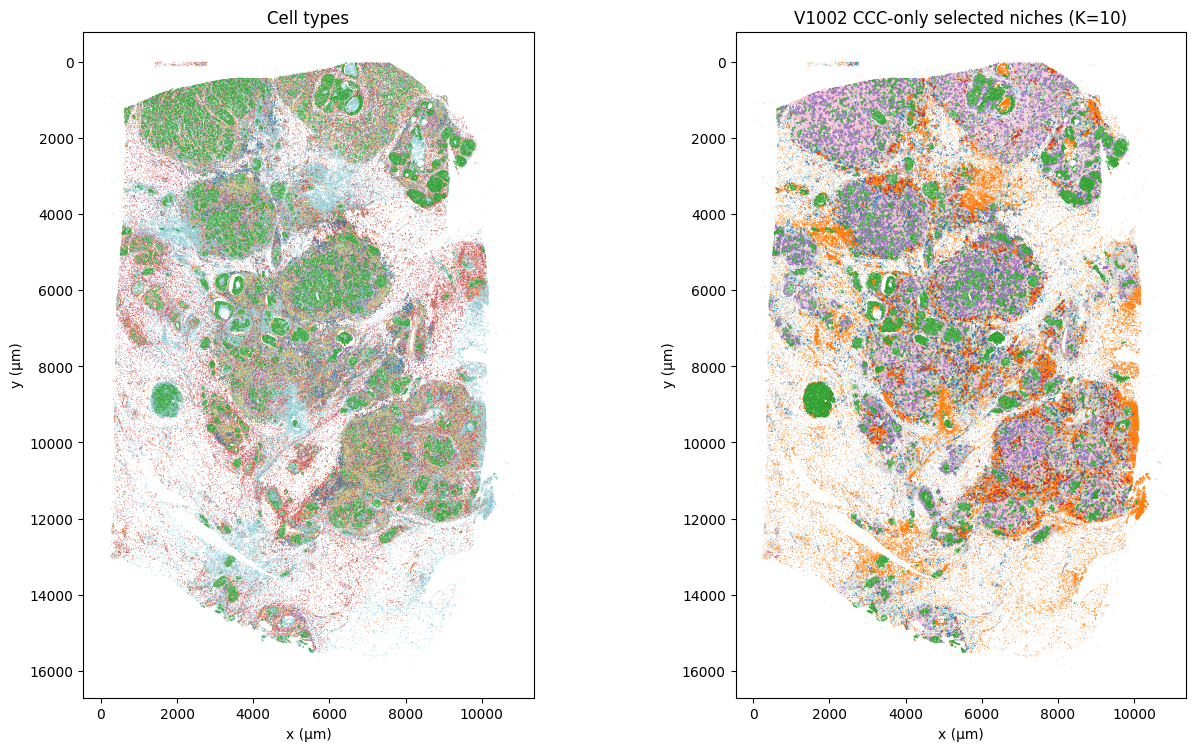

In [8]:
colors=plt.get_cmap('tab20',selected_K)(np.arange(selected_K)); type_colors=plt.get_cmap('tab20',T)(np.arange(T))
fig,axes=plt.subplots(1,2,figsize=(13,7.4),layout='constrained')
axes[0].scatter(coordinates[:,0],coordinates[:,1],c=type_colors[cell_type],s=.22,linewidths=0,rasterized=True); axes[0].set_title('Cell types')
axes[1].scatter(coordinates[:,0],coordinates[:,1],c=colors[niche],s=.22,linewidths=0,rasterized=True); axes[1].set_title(f'V1002 CCC-only selected niches (K={selected_K})')
for ax in axes: ax.set_aspect('equal'); ax.invert_yaxis(); ax.set(xlabel='x (µm)',ylabel='y (µm)')
plt.show()


## 5. Niche size and assignment confidence

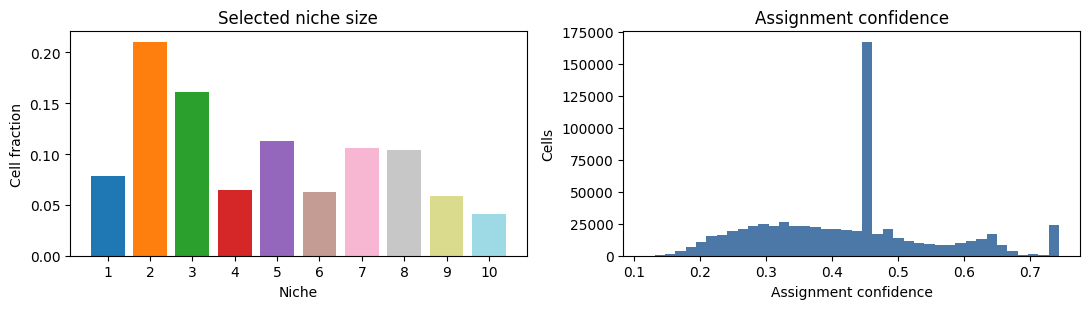

,niche,n_cells,fraction,mean_soft_usage
0,1,54982,0.078646,0.090786
1,2,147018,0.210293,0.137854
2,3,112488,0.160902,0.124027
3,4,45496,0.065077,0.065379
4,5,79264,0.113378,0.117562
5,6,44019,0.062964,0.086423
6,7,74008,0.105860,0.114792
7,8,72625,0.103882,0.108949
8,9,40844,0.058423,0.079687
9,10,28366,0.040574,0.074302


In [9]:
count_table=pd.DataFrame({'niche':np.arange(1,selected_K+1),'n_cells':counts,'fraction':fractions,'mean_soft_usage':np.asarray(Q).mean(0)})
count_table.to_csv(OUT/'niche_counts.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(11,3.2)); axes[0].bar(count_table.niche.astype(str),fractions,color=colors)
axes[0].set(xlabel='Niche',ylabel='Cell fraction',title='Selected niche size'); axes[1].hist(confidence,bins=40,color='#4c78a8')
axes[1].set(xlabel='Assignment confidence',ylabel='Cells',title='Assignment confidence'); fig.tight_layout(); plt.show()
display(count_table)


## 6. Cell types and individual niche maps

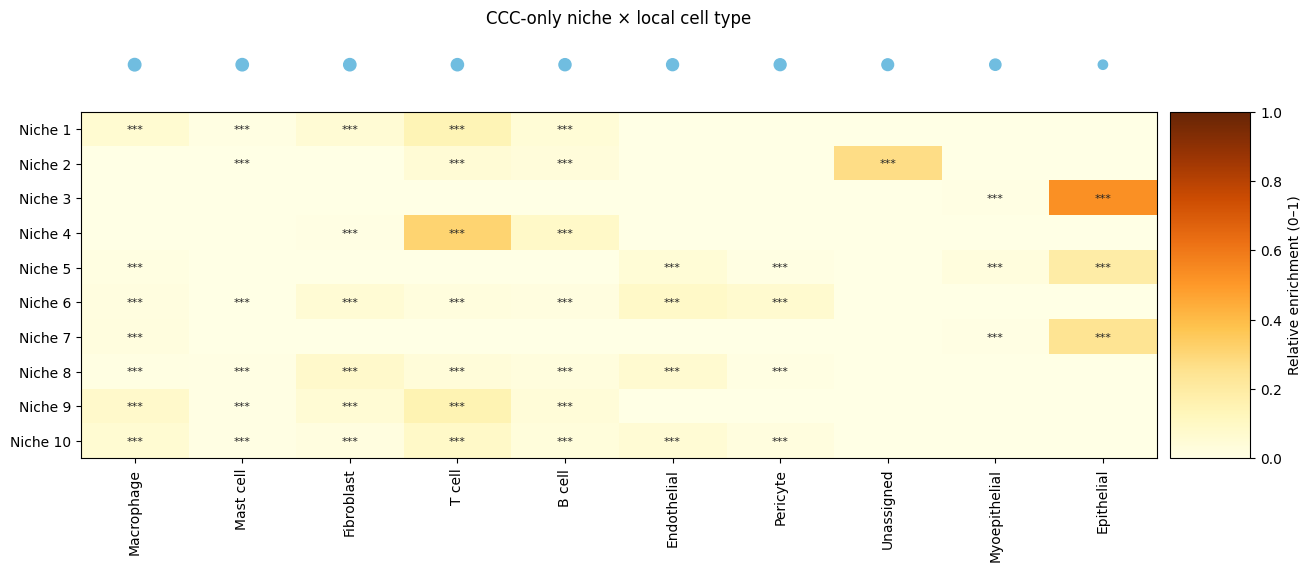

In [10]:
sizes=counts; baseline=C.mean(0); means=np.empty((selected_K,T)); pvalues=np.ones((selected_K,T))
for t in range(T):
    values=C[:,t].astype(float); ranks=rankdata(values,method='average'); rank_sum=np.bincount(niche,weights=ranks,minlength=selected_K)
    means[:,t]=np.bincount(niche,weights=values,minlength=selected_K)/np.maximum(sizes,1); outside=N-sizes
    u=rank_sum-sizes*(sizes+1)/2; sd=np.sqrt(sizes*outside*(N+1)*tiecorrect(ranks)/12); valid=sd>0
    pvalues[valid,t]=norm.sf((u[valid]-sizes[valid]*outside[valid]/2-.5)/sd[valid])
enrichment=np.clip((means-baseline[None,:])/np.maximum(1-baseline[None,:],1e-12),0,1)
mass=sizes[:,None]*means; share=mass/np.maximum(mass.sum(0,keepdims=True),1e-12)
entropy=-np.sum(np.where(share>0,share*np.log(np.maximum(share,1e-300)),0),axis=0)/np.log(selected_K)
order=np.argsort(-entropy,kind='stable'); enrichment,pvalues=enrichment[:,order],pvalues[:,order]; types=[label_categories[i] for i in order]
fig=plt.figure(figsize=(13,max(5.6,.32*selected_K+2)),layout='constrained'); grid=fig.add_gridspec(2,2,width_ratios=[20,1.5],height_ratios=[.8,4.2])
ax=fig.add_subplot(grid[1,0]); top=fig.add_subplot(grid[0,0],sharex=ax); bar=fig.add_subplot(grid[1,1]); legend=fig.add_subplot(grid[0,1])
im=ax.imshow(enrichment,cmap='YlOrBr',vmin=0,vmax=1,aspect='auto')
for r,c in np.ndindex(enrichment.shape):
    p=pvalues[r,c]; stars='***' if p<=1e-4 else '**' if p<=1e-3 else '*' if p<=.05 else ''
    if stars and enrichment[r,c]>0: ax.text(c,r,stars,ha='center',va='center',fontsize=8,color='white' if enrichment[r,c]>.65 else '#252525')
ax.set_xticks(np.arange(T),types,rotation=90); ax.set_yticks(np.arange(selected_K),[f'Niche {i+1}' for i in range(selected_K)])
top.scatter(np.arange(T),np.zeros(T),s=12+70*entropy[order],color='#70bde0'); top.set_axis_off(); top.set_title('CCC-only niche × local cell type')
fig.colorbar(im,cax=bar,label='Relative enrichment (0–1)'); legend.set_axis_off(); plt.show()


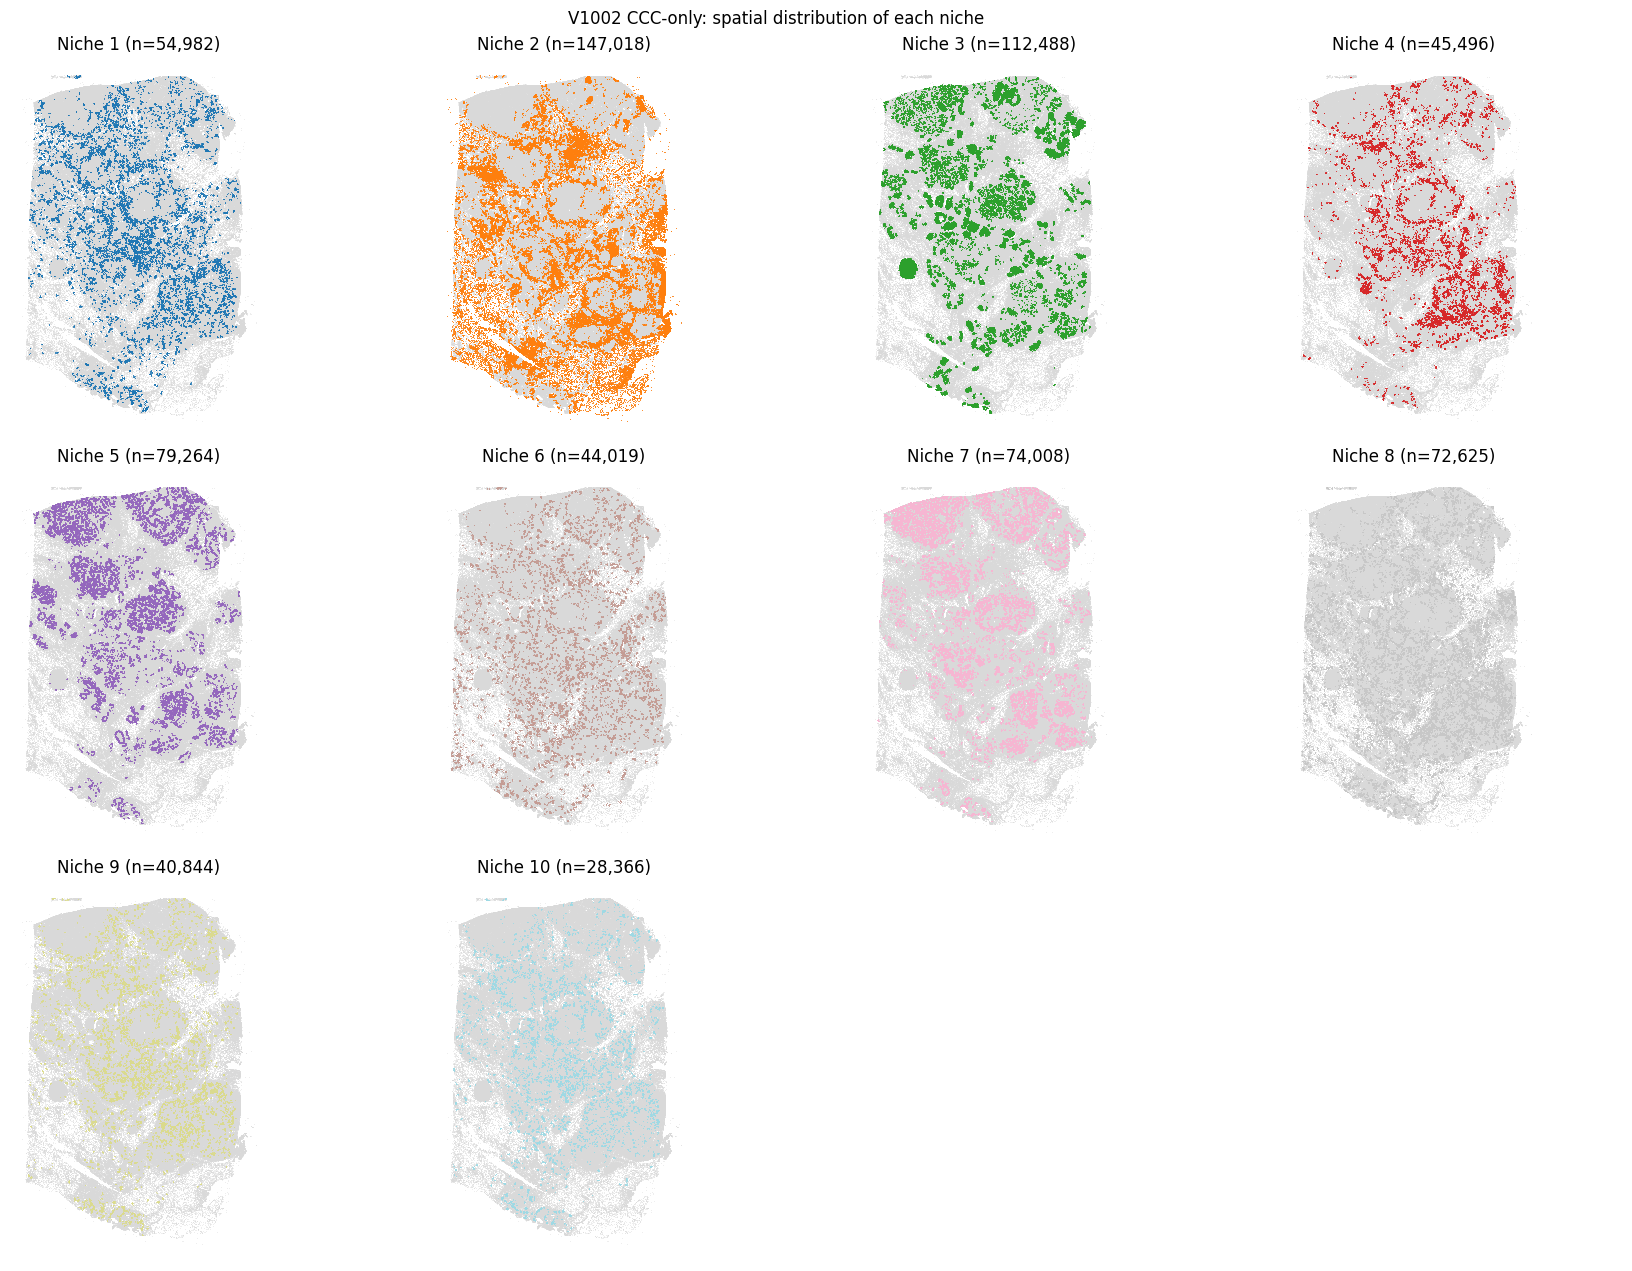

In [11]:
cols=4; rows=int(np.ceil(selected_K/cols)); fig,axes=plt.subplots(rows,cols,figsize=(17,4.2*rows),squeeze=False,layout='constrained')
for k,ax in enumerate(axes.flat[:selected_K]):
    take=niche==k; ax.scatter(coordinates[:,0],coordinates[:,1],c='#d9d9d9',s=.16,linewidths=0,rasterized=True)
    ax.scatter(coordinates[take,0],coordinates[take,1],c=[colors[k]],s=.38,linewidths=0,rasterized=True)
    ax.set(title=f'Niche {k+1} (n={take.sum():,})'); ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_axis_off()
for ax in axes.flat[selected_K:]: ax.set_axis_off()
fig.suptitle('V1002 CCC-only: spatial distribution of each niche'); plt.show()


## 7. Representative CCC programs

In [12]:
records=[]
for k in range(selected_K):
    for rank,f in enumerate(np.argsort(-H[k],kind='stable')[:15],1):
        row=ccc_mapping.iloc[f]; records.append({'niche':k+1,'rank':rank,'feature_id':f,'ccc':row.ccc,'sender':row.sender,'receiver':row.receiver,'lr':row.lr,'weight':H[k,f]})
top_ccc=pd.DataFrame(records); top_ccc.to_csv(OUT/'top_ccc.csv',index=False)
for k in range(1,selected_K+1):
    print(f'\nNiche {k}'); display(top_ccc.query('niche==@k')[['rank','ccc','weight']].reset_index(drop=True))
def grouped_markers(columns,name):
    frames=[]
    for k in range(selected_K):
        x=ccc_mapping[columns].copy(); x['weight']=H[k]; x=x.groupby(columns,as_index=False).weight.sum().nlargest(15,'weight'); x.insert(0,'niche',k+1); frames.append(x)
    result=pd.concat(frames,ignore_index=True); result.to_csv(OUT/name,index=False); return result
print('Top sender → receiver'); display(grouped_markers(['sender','receiver'],'top_sender_receiver.csv').groupby('niche').head(5))
print('Top ligand–receptor'); display(grouped_markers(['lr'],'top_lr.csv').groupby('niche').head(5))



Niche 1


,rank,ccc,weight
0,1,Fibroblast → Macrophage | CommuSpace_HS_06869,0.169193
1,2,Fibroblast → Macrophage | CommuSpace_HS_01093,0.117463
2,3,Fibroblast → Macrophage | CommuSpace_HS_01081,0.090396
3,4,Fibroblast → Macrophage | CommuSpace_HS_07429,0.061962
4,5,Macrophage → Fibroblast | CommuSpace_HS_04798,0.061962
5,6,Fibroblast → Macrophage | CommuSpace_HS_07427,0.033642
6,7,Epithelial → Macrophage | CommuSpace_HS_02696,0.032290
7,8,Macrophage → Pericyte | CommuSpace_HS_04798,0.019314
8,9,Pericyte → Macrophage | CommuSpace_HS_07429,0.019314
9,10,Endothelial → Macrophage | CommuSpace_HS_01081,0.017568



Niche 2


,rank,ccc,weight
0,1,Epithelial → Epithelial | CommuSpace_HS_07453,0.011581
1,2,Fibroblast → Epithelial | CommuSpace_HS_07453,0.011178
2,3,Epithelial → Epithelial | CommuSpace_HS_07452,0.010891
3,4,Fibroblast → Epithelial | CommuSpace_HS_07452,0.010844
4,5,Epithelial → Epithelial | CommuSpace_HS_02693,0.010574
5,6,Epithelial → Endothelial | CommuSpace_HS_07454,0.010504
6,7,Fibroblast → Macrophage | CommuSpace_HS_06869,0.010445
7,8,Fibroblast → Macrophage | CommuSpace_HS_07452,0.010267
8,9,Fibroblast → Endothelial | CommuSpace_HS_07454,0.010174
9,10,Fibroblast → Macrophage | CommuSpace_HS_00946,0.010122



Niche 3


...

,rank,ccc,weight
0,1,Endothelial → Macrophage | CommuSpace_HS_01729,0.170230
1,2,Endothelial → Macrophage | CommuSpace_HS_01750,0.092342
2,3,Pericyte → Macrophage | CommuSpace_HS_01729,0.075456
3,4,Endothelial → Macrophage | CommuSpace_HS_07452,0.050464
4,5,Pericyte → Macrophage | CommuSpace_HS_01750,0.046350
5,6,Pericyte → Macrophage | CommuSpace_HS_07452,0.039066
6,7,Fibroblast → Macrophage | CommuSpace_HS_07452,0.023756
7,8,Endothelial → Macrophage | CommuSpace_HS_06869,0.020573
8,9,Endothelial → Macrophage | CommuSpace_HS_07427,0.018363
9,10,Endothelial → T cell | CommuSpace_HS_01729,0.017898


Top sender → receiver


,niche,sender,receiver,weight
0,1,Fibroblast,Macrophage,0.509549
1,1,Macrophage,Fibroblast,0.061962
2,1,Endothelial,Macrophage,0.060972
3,1,Epithelial,Macrophage,0.048983
4,1,Pericyte,Macrophage,0.037145
15,2,Fibroblast,Epithelial,0.122365
16,2,Epithelial,Epithelial,0.114278
17,2,Fibroblast,Endothelial,0.089807
18,2,Endothelial,Epithelial,0.079057
19,2,Fibroblast,Macrophage,0.061452


Top ligand–receptor


,niche,lr,weight
0,1,CommuSpace_HS_06869,0.184125
1,1,CommuSpace_HS_01093,0.117463
2,1,CommuSpace_HS_01081,0.115325
3,1,CommuSpace_HS_04798,0.097941
4,1,CommuSpace_HS_07429,0.097941
15,2,CommuSpace_HS_07452,0.105683
16,2,CommuSpace_HS_01729,0.054064
17,2,CommuSpace_HS_07453,0.043622
18,2,CommuSpace_HS_07450,0.039870
19,2,CommuSpace_HS_00391,0.033139


## 8. Selected niche × representative CCC heatmap

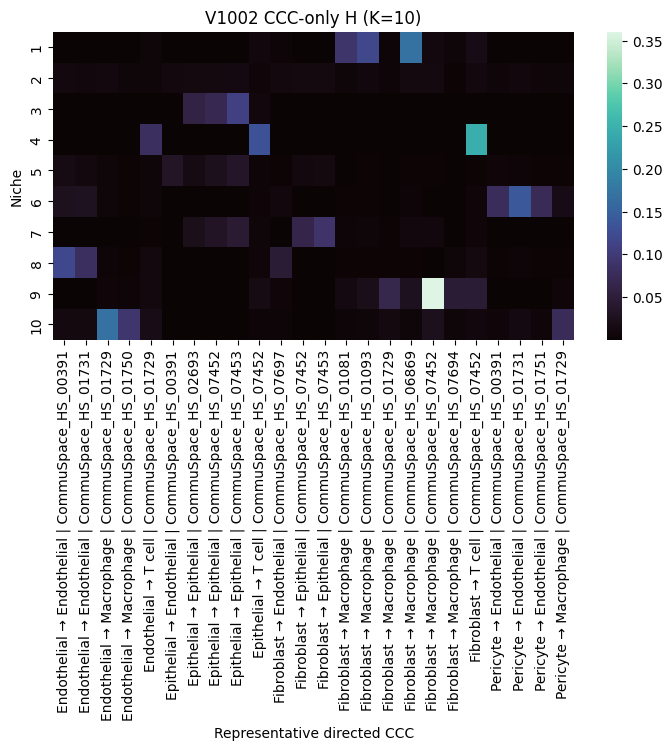

In [13]:
features=np.unique(np.concatenate([np.argsort(-row)[:3] for row in H])); labels=ccc_mapping.iloc[features].ccc.tolist()
fig,ax=plt.subplots(figsize=(max(7,.35*len(features)),max(4,.35*selected_K)))
sns.heatmap(H[:,features],cmap='mako',xticklabels=labels,yticklabels=np.arange(1,selected_K+1),ax=ax)
ax.set(xlabel='Representative directed CCC',ylabel='Niche',title=f'V1002 CCC-only H (K={selected_K})'); ax.tick_params(axis='x',rotation=90); plt.show()


## 9. Latent-program contribution to selected niches

In [14]:
mean_p=np.zeros((selected_K,32))
for k in range(selected_K): mean_p[k]=np.asarray(P32[niche==k]).mean(0)
program_niche=mean_p.argmax(0)
program_mapping=pd.DataFrame({'program_id':np.arange(1,33),'final_niche_id':program_niche+1,
    'global_mean_usage':np.asarray(P32).mean(0),'niche_specific_usage':mean_p[program_niche,np.arange(32)]})
program_mapping.to_csv(OUT/'program32_to_niche.csv',index=False)
display(program_mapping.groupby('final_niche_id').agg(latent_programs=('program_id',lambda x:', '.join(map(str,x))),total_usage=('global_mean_usage','sum')).reset_index())


,final_niche_id,latent_programs,total_usage
0,1,"6, 15, 23",0.116724
1,3,"8, 19, 22, 28, 29",0.233987
2,4,21,0.085047
3,5,"1, 2, 9, 12, 24, 26",0.109094
4,6,"7, 18",0.056240
5,7,"11, 13, 16, 17, 25, 30",0.114059
6,8,"4, 5, 10, 14, 20, 31, 32",0.203564
7,9,3,0.049128
8,10,27,0.032153


## 10. Selected K versus original fixed K=8 CCC-only

In [15]:
w8_path=OUT/'W8_fixed.npy'; h8_path=OUT/'H8_fixed.npy'
if w8_path.is_file() and h8_path.is_file(): W8=np.load(w8_path,mmap_mode='r'); H8=np.load(h8_path)
else:
    fit8=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=8)
    W8=np.maximum(fit8.W.numpy(),0); W8/=np.maximum(W8.sum(1,keepdims=True),1e-12); H8=np.maximum(fit8.dictionaries['HI'].numpy(),0)
    np.save(w8_path,W8); np.save(h8_path,H8); W8=np.load(w8_path,mmap_mode='r')
fixed_labels=np.asarray(W8).argmax(1); fixed_conf=np.asarray(W8).max(1); fixed_counts=np.bincount(fixed_labels,minlength=8)
display(pd.DataFrame({'niches':[8,selected_K],'largest_niche_fraction':[fixed_counts.max()/N,fractions.max()],
    'tiny_niche_fraction':[(fixed_counts[fixed_counts<max(20,int(.005*N))].sum()/N),fractions[counts<max(20,int(.005*N))].sum()],
    'mean_assignment_confidence':[fixed_conf.mean(),confidence.mean()]},index=['Original fixed K=8',f'Automatic K={selected_K}']).round(4))


,niches,largest_niche_fraction,tiny_niche_fraction,mean_assignment_confidence
Original fixed K=8,8,0.3132,0.0,0.5471
Automatic K=10,10,0.2103,0.0,0.4239


## 11. Summary

In [16]:
top=top_ccc.query('rank==1').set_index('niche').ccc
print(f'Selected K: {selected_K}')
print(f'All selected niches used: {(counts>0).all()}')
print(f'Largest niche fraction: {fractions.max():.2%}')
print(f'Tiny-niche cell fraction: {fractions[counts<max(20,int(.005*N))].sum():.2%}')
print(f'Mean assignment confidence: {confidence.mean():.3f}')
display(top.rename('Top representative CCC').to_frame())


Selected K: 10
All selected niches used: True
Largest niche fraction: 21.03%
Tiny-niche cell fraction: 0.00%
Mean assignment confidence: 0.424


,Top representative CCC
niche,
1,Fibroblast → Macrophage | CommuSpace_HS_06869
2,Epithelial → Epithelial | CommuSpace_HS_07453
3,Epithelial → Epithelial | CommuSpace_HS_07453
4,Fibroblast → T cell | CommuSpace_HS_07452
5,Epithelial → Epithelial | CommuSpace_HS_07453
6,Pericyte → Endothelial | CommuSpace_HS_01731
7,Fibroblast → Epithelial | CommuSpace_HS_07453
8,Endothelial → Endothelial | CommuSpace_HS_00391
9,Fibroblast → Macrophage | CommuSpace_HS_07452
